# tap.tapecho~ — the echo, measured

The multi-head tape echo of the Copicat / Space Echo school (`taptools/tapecho.h` over the
shared `taptools/tape_loop.h`): one record head, a span of moving tape, several playback heads
at fixed positions along it, and a regeneration path from the heads back to the record head.

Two claims carry the kernel, and both are measured below. The first is structural — **this
kernel is composition, not construction**: with the tape path neutralized it is *bitwise* the
plain Hermite multitap of `delay.h`, which is what makes "`tape_loop.h` is a library" a
measurement rather than a slogan. The second is the design statement — **regeneration is
allowed past unity** into deliberate sound-on-sound self-oscillation, bounded by the
saturator (`vca::swing_shape`, ≤ 1/drive) rather than by a feedback cap, and capped back to
1.0 the moment drive leaves.

Every trace drives the **shipping C++** through `tools/capi` via ctypes.

Sections: **1** the head layout · **2** the null test against `delay.h` · **3** generation loss
per pass · **4** past unity, and the bound that holds it · **5** the transport

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

def echo(**params):
    # A machine with the transport parked and the wear path neutral: sections opt in.
    base = dict(smooth_ms=0, wow=(0, 0), flutter=(0, 0), regen=0.0, drive=0.0,
                darken_hz=20000.0, input_level=1.0, mix=100)
    base.update(params)
    return tap.TapEcho(sr, 4.0, **base)

def goertzel(x, f):
    n = np.arange(x.size)
    return 2.0 * np.abs(np.dot(x, np.exp(-2j * np.pi * f * n / sr))) / x.size

## 1 · The head layout

`span_ms` is the motor: the delay of a head at the far end of the path (ratio 1.0). Every other
head sits at `span_ms * ratio`, so moving the motor moves the whole layout together, as a tape
speed does. The defaults are four evenly spaced heads — 0.25, 0.5, 0.75, 1.0 — a nominal layout
chosen because it is neutral and audibly "a tape echo"; real machines' head positions vary by
model and unit and none are claimed as measured here.

An impulse into a 400 ms span, no regeneration, shows the four returns exactly on their
positions. (Pinned by the kernel scenario *"each head echoes at its own position along the tape
path"*.)

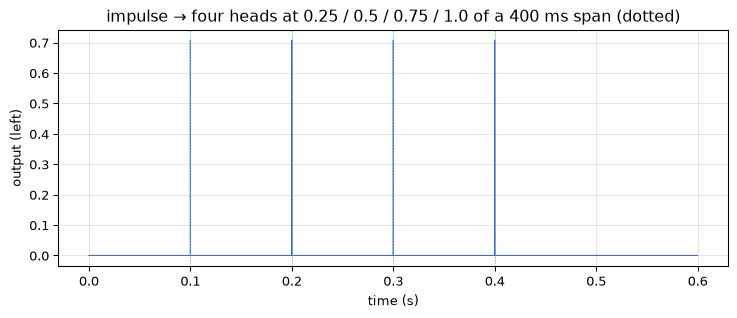

head 0 (ratio 0.25): return at 100.000 ms, level 0.707106781  (centre-pan law cos(pi/4) = 0.707106781)
head 1 (ratio 0.50): return at 200.000 ms, level 0.707106781  (centre-pan law cos(pi/4) = 0.707106781)
head 2 (ratio 0.75): return at 300.000 ms, level 0.707106781  (centre-pan law cos(pi/4) = 0.707106781)
head 3 (ratio 1.00): return at 400.000 ms, level 0.707106781  (centre-pan law cos(pi/4) = 0.707106781)


In [2]:
span = 0.400
m = echo(span_ms=span * 1000, heads=4)
x = np.zeros(int(0.6 * sr)); x[0] = 1.0
left, right = m.process(x)

t = np.arange(left.size) / sr
fig, ax = plt.subplots()
ax.plot(t, left, color=C[0], lw=0.8)
for i in range(4):
    ax.axvline(span * (i + 1) / 4, color=C[3], lw=0.8, ls=":")
ax.set_xlabel("time (s)"); ax.set_ylabel("output (left)")
ax.set_title("impulse → four heads at 0.25 / 0.5 / 0.75 / 1.0 of a 400 ms span (dotted)")
plt.show()

for i in range(4):
    k = int(span * (i + 1) / 4 * sr)
    print(f"head {i} (ratio {(i + 1) / 4:.2f}): return at {k / sr * 1000:7.3f} ms, "
          f"level {left[k]:.9f}  (centre-pan law cos(pi/4) = {np.cos(np.pi / 4):.9f})")

## 2 · The null test — the echo *is* the multitap of `delay.h`

Neutralize the tape path (no transport error, no wear in play because there is no regeneration)
and a one-head echo must reduce to the plain fractional delay this library already had. It does,
**bitwise** — same Hermite read at the same fractional position under the same equal-power pan
law — for a span deliberately chosen not to be a whole number of samples.

This is the load-bearing structural claim: the tape echo adds a head layout, a transport, and a
worn regeneration path *on top of* machinery that is shared, not reimplemented. Both objects are
reached here through the same C ABI, so the comparison crosses the same boundary the Max
externals do. (Pinned by *"with the tape path neutral, a one-head echo is bitwise the multitap
of delay.h"*.)

In [3]:
span_ms = 137.31  # deliberately not a whole number of samples
rng = np.random.default_rng(2463534242)
x = rng.uniform(-1, 1, int(0.5 * sr))

e = echo(span_ms=span_ms, heads=1, ratios=[1.0], levels=[1.0], pans=[0.0])
el, er = e.process(x)

ref = tap.Multitap(sr, 1000.0, smooth_ms=0, taps=1)
ref.set(times=[span_ms], gains=[1.0], pans=[0.0])
rl, rr = ref.process(x)

print(f"left  bitwise identical: {np.array_equal(el, rl)}   max |diff| = {np.max(np.abs(el - rl))}")
print(f"right bitwise identical: {np.array_equal(er, rr)}   max |diff| = {np.max(np.abs(er - rr))}")
print(f"and not vacuous — both are non-trivial signals: rms = {np.sqrt(np.mean(el ** 2)):.4f}")

left  bitwise identical: True   max |diff| = 0.0
right bitwise identical: True   max |diff| = 0.0
and not vacuous — both are non-trivial signals: rms = 0.3367


## 3 · Generation loss, one pass at a time

Each trip through the regeneration path is one pass of `tape_loop.h`'s `wear`: a darkening
one-pole lowpass, the bounded soft saturator, then the normalized DC blocker. At drive 0 the
saturator is exactly linear, so the per-pass ratio is precisely `regen * |H_wear(f)|` and can be
predicted analytically — the same formulas the kernel applies, computed independently here.

A two-tone burst (one tone well above the darkening corner, one well below) through a one-head
echo shows both sides of the tilt: the highs die fast, the lows barely fade. That is the honest
tape story — wear is a tilt, not a fader.

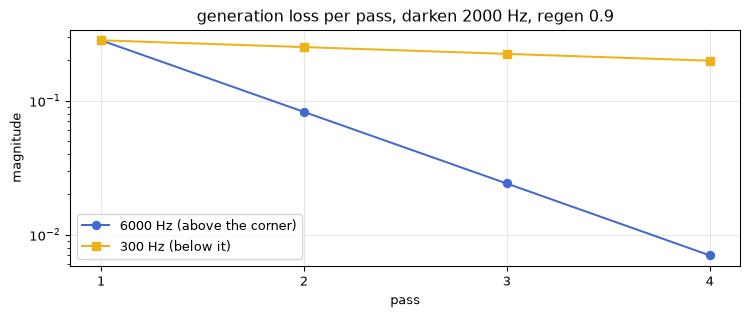

predicted per-pass ratio   hi 0.2920   lo 0.8898
measured  per-pass ratio   hi 0.2915   lo 0.8895


In [4]:
def wear_gain(f, cutoff_hz):
    w = 2 * np.pi * f / sr
    a = 1.0 - np.exp(-2 * np.pi * cutoff_hz / sr)
    ejw = np.exp(-1j * w)
    lp = np.abs(a / (1 - (1 - a) * ejw))
    r, nm = 0.999, (1 + 0.999) / 2
    return lp * np.abs(nm * (1 - ejw) / (1 - r * ejw))

f_hi, f_lo, cutoff, regen, span = 6000.0, 300.0, 2000.0, 0.9, 0.25
m = echo(span_ms=span * 1000, heads=1, ratios=[1.0], regen=regen, drive=0.0, darken_hz=cutoff)
n = int(1.5 * sr)
t = np.arange(n) / sr
burst = np.zeros(n)
w = int(0.1 * sr)
burst[:w] = 0.4 * np.sin(2 * np.pi * f_hi * t[:w]) + 0.4 * np.sin(2 * np.pi * f_lo * t[:w])
y, _ = m.process(burst)

loop = int(span * sr)
hi = np.array([goertzel(y[k * loop : k * loop + w], f_hi) for k in range(1, 5)])
lo = np.array([goertzel(y[k * loop : k * loop + w], f_lo) for k in range(1, 5)])

fig, ax = plt.subplots()
passes = np.arange(1, 5)
ax.semilogy(passes, hi, color=C[0], marker="o", label=f"{f_hi:.0f} Hz (above the corner)")
ax.semilogy(passes, lo, color=C[1], marker="s", label=f"{f_lo:.0f} Hz (below it)")
ax.set_xlabel("pass"); ax.set_ylabel("magnitude"); ax.set_xticks(passes)
ax.set_title(f"generation loss per pass, darken {cutoff:.0f} Hz, regen {regen}")
ax.legend()
plt.show()

print(f"predicted per-pass ratio   hi {regen * wear_gain(f_hi, cutoff):.4f}   "
      f"lo {regen * wear_gain(f_lo, cutoff):.4f}")
print(f"measured  per-pass ratio   hi {np.mean(hi[1:] / hi[:-1]):.4f}   "
      f"lo {np.mean(lo[1:] / lo[:-1]):.4f}")

## 4 · Past unity, and the bound that holds it

`delay.h` caps feedback at 0.99 so its loop is always contractive. `discreet.h` lets
regeneration reach exactly 1.0 because `|H_wear| ≤ 1` makes 1.0 sustain without growing. This
kernel goes one step further and allows regeneration *past* unity — the sound-on-sound howl a
tape echo is reached for live — and it stays bounded because the saturator does: with drive
engaged, `swing_shape` is bounded by `1/drive` no matter what the loop gain is.

Because that bound only exists while the saturator is engaged, the cap is **drive-dependent and
applied per sample**: at drive 0 the effective regeneration falls back to 1.0, whatever the
target says. Below, the same excessive target (1.4) at four drives plus the drive-0 case: every
one plateaus, and every one stays under the analytic ceiling the saturator sets.

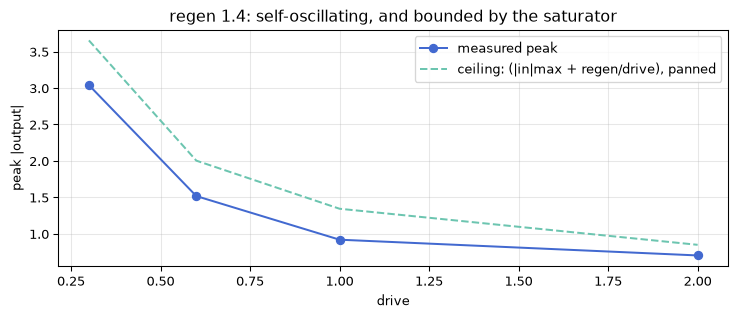

 drive   rms mid  rms late   growth    peak  ceiling  finite
   0.3    2.4777    2.4935   1.0064  3.0400   3.6534  True
   0.6    1.2357    1.2439   1.0066  1.5174   2.0035  True
   1.0    0.7395    0.7459   1.0086  0.9189   1.3435  True
   2.0    0.3695    0.3723   1.0075  0.7027   0.8485  True
   0.0    0.0522    0.0473   0.9054  0.6608       --  True   <- drive 0: effective regen capped back to 1.0, still no growth


In [5]:
def plateau(drive, regen=1.4, seconds=14.0):
    m = echo(span_ms=250.0, heads=1, ratios=[1.0], regen=regen, drive=drive, darken_hz=6000.0)
    x = np.zeros(int(seconds * sr))
    burst = int(0.5 * sr)
    x[:burst] = 0.5 * np.random.default_rng(7).uniform(-1, 1, burst)
    y, _ = m.process(x)
    mid = y[int(0.55 * y.size) : int(0.75 * y.size)]
    late = y[int(0.75 * y.size) :]
    return (np.sqrt(np.mean(mid ** 2)), np.sqrt(np.mean(late ** 2)),
            np.max(np.abs(y)), np.all(np.isfinite(y)))

drives = [0.3, 0.6, 1.0, 2.0]
rows = [(d,) + plateau(d) for d in drives]
capped = plateau(0.0)

# The analytic ceiling on the tape is |in|max + regen/drive: the saturator bounds the returned
# signal by 1/drive, and the record head adds the direct send on top. The single centre-panned
# head then scales it by cos(pi/4). (Looser bounds exist — the DC blocker's L1 gain is ~2 — but
# real signals do not excite the worst case, which is why the measured curve sits below.)
ceiling = [np.cos(np.pi / 4) * (0.5 + 1.4 / d) for d in drives]

fig, ax = plt.subplots()
ax.plot(drives, [r[3] for r in rows], color=C[0], marker="o", label="measured peak")
ax.plot(drives, ceiling, color=C[3], ls="--", label="ceiling: (|in|max + regen/drive), panned")
ax.set_xlabel("drive"); ax.set_ylabel("peak |output|")
ax.set_title("regen 1.4: self-oscillating, and bounded by the saturator")
ax.legend()
plt.show()

print(f"{'drive':>6} {'rms mid':>9} {'rms late':>9} {'growth':>8} {'peak':>7} {'ceiling':>8}  finite")
for (d, mid, late, pk, fin), cap in zip(rows, ceiling):
    print(f"{d:6.1f} {mid:9.4f} {late:9.4f} {late / mid:8.4f} {pk:7.4f} {cap:8.4f}  {fin}")
mid, late, pk, fin = capped
print(f"{0.0:6.1f} {mid:9.4f} {late:9.4f} {late / mid:8.4f} {pk:7.4f} {'--':>8}  {fin}"
      f"   <- drive 0: effective regen capped back to 1.0, still no growth")

## 5 · The transport

Wow and flutter are `tape_loop.h`'s deterministic periodic pair — a slow deep sine and a faster
shallow one, summed into a read-position offset shared by every head (one motor moves the whole
path). Periodic-only is a family decision, not an oversight: it keeps renders and tests
bit-exactly reproducible, and the stochastic capstan term is a documented non-goal.

A sinusoidally modulated read swings the playback ratio by `depth · 2π · rate`, which predicts
the peak pitch deviation in cents. Measured out of the output below by zero-crossing period,
and confirmed bit-exact across two runs.

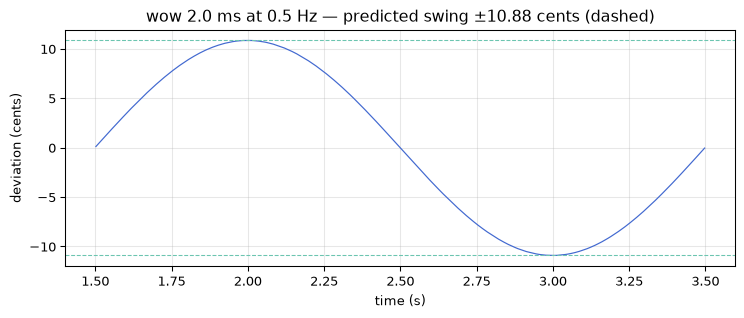

predicted peak deviation  10.88 cents
measured  peak deviation  10.91 cents


two runs bitwise identical: True


In [6]:
depth_ms, rate_hz = 2.0, 0.5
predicted = 1200 / np.log(2) * depth_ms * 1e-3 * 2 * np.pi * rate_hz

def render():
    m = echo(span_ms=1000.0, heads=1, ratios=[1.0], wow=(depth_ms, rate_hz))
    t = np.arange(int(4.5 * sr)) / sr
    y, _ = m.process(0.8 * np.sin(2 * np.pi * 440.0 * t))
    return y

y = render()

# Instantaneous pitch by zero-crossing spacing, over the filled-tape region.
seg = y[int(1.5 * sr) : int(3.5 * sr)]
cross = np.where((seg[:-1] <= 0) & (seg[1:] > 0))[0]
frac = seg[cross] / (seg[cross] - seg[cross + 1])
times = (cross + frac) / sr
hz = 1.0 / np.diff(times)
cents = 1200 * np.log2(hz / 440.0)

fig, ax = plt.subplots()
ax.plot(times[:-1] + 1.5, cents, color=C[0], lw=0.9)
for s in (+predicted, -predicted):
    ax.axhline(s, color=C[3], lw=0.8, ls="--")
ax.set_xlabel("time (s)"); ax.set_ylabel("deviation (cents)")
ax.set_title(f"wow {depth_ms} ms at {rate_hz} Hz — predicted swing ±{predicted:.2f} cents (dashed)")
plt.show()

print(f"predicted peak deviation {predicted:6.2f} cents")
print(f"measured  peak deviation {np.max(np.abs(cents)):6.2f} cents")
print(f"two runs bitwise identical: {np.array_equal(y, render())}")

## Checkpoint

- The head layout is exact: each head returns at `span · ratio`, and the motor moves them
  together.
- With the tape path neutral the echo is **bitwise** `delay.h`'s multitap — the kernel is
  composition over `tape_loop.h`, measured, not asserted.
- Generation loss per pass matches the analytic wear transfer on both sides of the corner.
- Regeneration past unity self-oscillates and stays under the saturator's ceiling at every
  drive measured; at drive 0 the
  effective value is capped back to 1.0 and still does not grow.
- The transport bends pitch by the predicted amount and is bit-exactly reproducible.